# Causal discovery on CausalARC

Jacqueline Maasch | August 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from   matplotlib import colors
import seaborn as sns
import json
import platform
import ast
from itertools import permutations,product

from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils
import networkx as nx
from dodiscover.metrics import structure_hamming_dist

# View versioning.
print("python version     :", platform.python_version())
print("numpy version      :", np.__version__)
print("pandas version     :", pd.__version__)
print("matplotlib version :", matplotlib.__version__)
print("seaborn version    :", sns.__version__)

/Users/jmaasch/anaconda3/envs/icp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


python version     : 3.10.13
numpy version      : 1.26.3
pandas version     : 2.1.4
matplotlib version : 3.8.0
seaborn version    : 0.12.2


# Define functions

In [2]:
# Adapted from https://github.com/jmaasch/causal_arc/blob/main/causal_arc/carc_tasks_logical.py.
def SCMdky5(size: tuple = (5,5), 
            fun: str = "and", # "or", "xor", "and"
            upper_color: int = 2,
            lower_color: int = 6,
            output_color: int = 7):

    if fun == "or":
        fun = np.logical_or
        fun_str = "np.logical_or"
    elif fun == "and":
        fun = np.logical_and
        fun_str = "np.logical_and"
    elif fun == "xor":
        fun = np.logical_xor
        fun_str = "np.logical_xor"
    else:
        raise ValueError("Invalid input: fun must be in ['or', 'and', 'xor'].")
    
    upper = np.random.choice([0,upper_color], size = size)
    lower = np.random.choice([0,lower_color], size = size)
    x = np.concatenate((upper,lower), axis = 0).astype(int)

    y = fun(upper,lower).astype(int)
    y *= output_color
    return x,y,(upper,lower)

In [3]:
def get_data(n: int = 1000,
             size: tuple = (4,4),
             fun: str = "and"):
    
    x_list = []
    y_list = []
    
    for i in range(n):
        x,y,_ = SCMdky5(fun = fun, size = size)
    
        # Flatten in row-major (C-style) order.
        x = x.flatten(order = "C")
        y = y.flatten(order = "C")
        x_list.append(x)
        y_list.append(y)
    
    x,y,_ = SCMdky5(size)
    x_idx = np.indices(x.shape, sparse = False)
    x_idx_rows = x_idx[0].flatten(order = "C")
    x_idx_cols = x_idx[1].flatten(order = "C")
    x_idx = list(zip(x_idx_rows,x_idx_cols))
    
    y_idx = np.indices(y.shape, sparse = False)
    y_idx_rows = y_idx[0].flatten(order = "C")
    y_idx_cols = y_idx[1].flatten(order = "C")
    y_idx = list(zip(y_idx_rows,y_idx_cols))
    
    df_x = pd.DataFrame(x_list, columns = [f"x_{c[0]}_{c[1]}" for c in x_idx])
    df_y = pd.DataFrame(y_list, columns = [f"y_{c[0]}_{c[1]}" for c in y_idx])    
    df = pd.concat([df_x,df_y], axis = 1)

    '''
    # Sanity check.
    y_0 = list(df_y["y_0_0"].to_numpy().astype(bool))
    x_0 = list(np.logical_and(df_x["x_0_0"].to_list(),df_x["x_4_0"].to_list()))
    y_0
    
    assert x_0 == y_0
    
    y_0 = list(df_y["y_1_0"].to_numpy().astype(bool))
    x_0 = list(np.logical_and(df_x["x_1_0"].to_list(),df_x["x_5_0"].to_list()))
    y_0
    
    assert x_0 == y_0
    '''
    
    return df

# Get ground truth

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

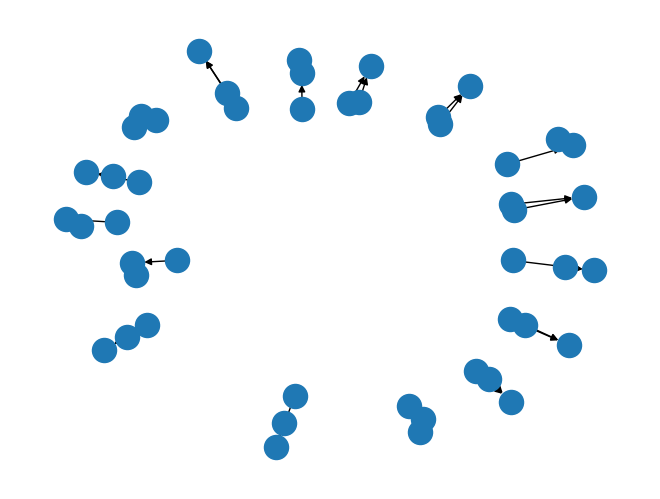

In [4]:
# True adjacency matrix.
size = (4,4)
x,y,_ = SCMdky5(size)
parent_dict = dict()
for i in range(y.shape[0]):
    for j in range(y.shape[1]):
        parent_dict[f"x_{i}_{j}"] = [f"y_{i}_{j}"]
        parent_dict[f"x_{i+4}_{j}"] = [f"y_{i}_{j}"]
g_true = nx.from_dict_of_lists(parent_dict, create_using = nx.DiGraph)
a_true = nx.to_numpy_array(g_true, nodelist = sorted(g_true.nodes())).astype(int)
display(a_true)
nx.draw(g_true)

# Generate data

## logical and

In [5]:
size = (4,4)
fun = "and"
n_list = [1000,5000,10000]
df_and_list = [get_data(n = n, size = size, fun = fun) for n in n_list]

In [6]:
df_and_list[0]

,x_0_0,x_0_1,x_0_2,x_0_3,x_1_0,x_1_1,x_1_2,x_1_3,x_2_0,x_2_1,...,y_1_2,y_1_3,y_2_0,y_2_1,y_2_2,y_2_3,y_3_0,y_3_1,y_3_2,y_3_3
0,0,0,2,0,2,0,0,0,2,0,...,0,0,0,0,7,0,0,0,0,0
1,0,2,0,2,0,2,2,2,2,0,...,0,7,0,0,0,0,0,0,0,0
2,0,0,2,0,2,0,2,2,2,0,...,7,0,0,0,0,0,0,7,0,7
3,2,0,2,0,0,2,2,0,2,0,...,0,0,0,0,0,0,7,7,0,7
4,2,0,0,2,2,2,0,2,2,2,...,0,7,0,7,0,0,0,0,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,2,0,0,2,0,2,...,0,7,0,7,0,0,0,0,0,0
996,2,2,0,0,2,2,2,0,0,2,...,0,0,0,7,0,0,0,0,0,0
997,2,0,0,0,2,2,2,2,0,0,...,0,0,0,0,7,0,7,7,0,0
998,0,0,2,0,0,0,2,2,2,2,...,7,0,0,7,0,0,0,0,7,7


## logical or

In [7]:
size = (4,4)
fun = "or"
n_list = [1000,5000,10000]
df_or_list = [get_data(n = n, size = size, fun = fun) for n in n_list]

## logical xor

In [8]:
size = (4,4)
fun = "xor"
n_list = [1000,5000,10000]
df_xor_list = [get_data(n = n, size = size, fun = fun) for n in n_list]

# PC algorithm

In [9]:
alpha = 0.01

## logical and

Depth=2, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 3431.57it/s]


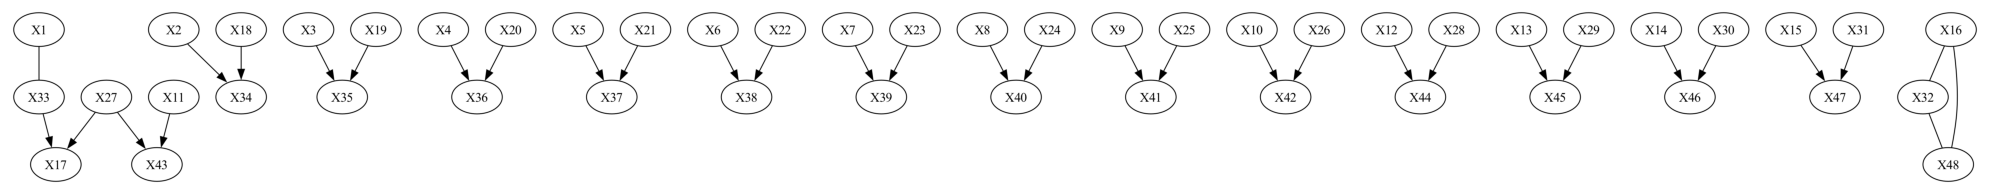

SHD @ n = 1000: 2.0


Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 1316.32it/s]


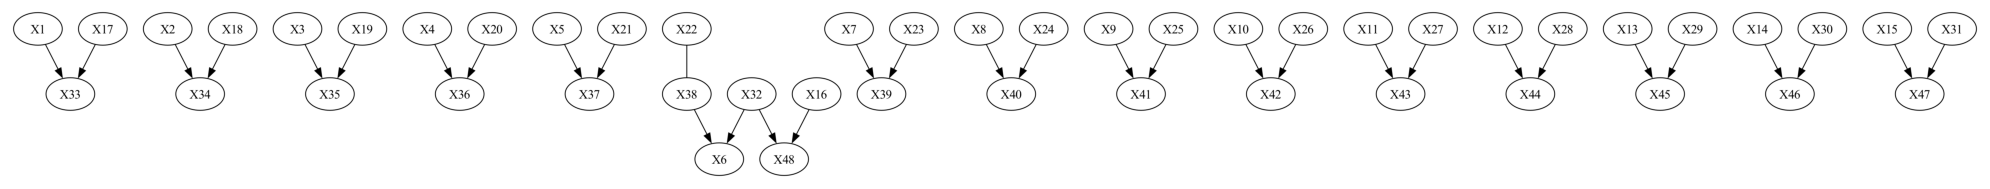

SHD @ n = 5000: 1.0


Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 1225.68it/s]


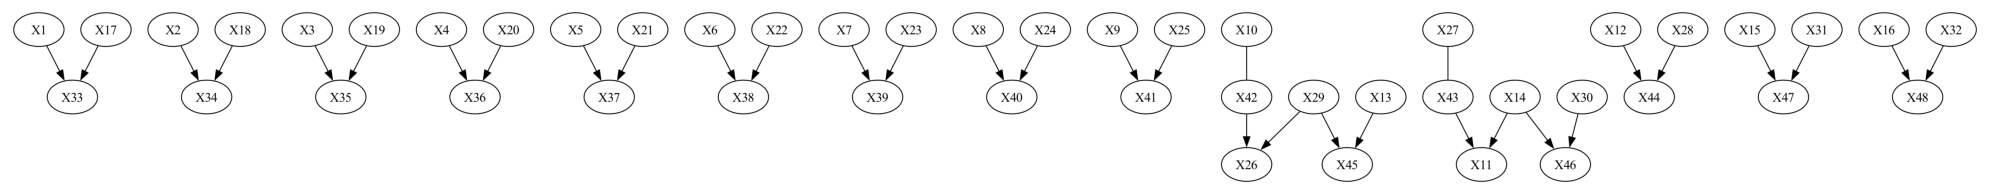

SHD @ n = 10000: 2.0


In [10]:
shd_and_list = []
ge_and_list = []
for df,n in zip(df_and_list,n_list):
    g_pred = pc(df.to_numpy(), indep_test = "chisq", alpha = alpha)

    # Visualization using pydot.
    g_pred.draw_pydot_graph()
    
    # Save the graph.
    pyd = GraphUtils.to_pydot(g_pred.G, labels = list(df.columns))
    pyd.write_png(f"pc_and_{n}.png")

    # Convert to networkx.
    a_pred = g_pred.G.graph.copy()
    a_pred = np.triu(a_pred)
    a_pred[a_pred == -1] = 1
    g_pred_nx = nx.from_numpy_array(a_pred, create_using = nx.DiGraph)

    # Evaluate.
    shd = structure_hamming_dist(g_true, g_pred_nx, double_for_anticausal = False)
    print(f"SHD @ n = {n}: {shd}")
    shd_and_list.append(shd)
    '''
    ge = nx.optimize_graph_edit_distance(g_true, g_pred_nx)
    for v in ge:
        print(v)
    print(f"GE @ n = {n}: {ge}")
    ge_and_list.append(ge)
    '''

## logical or

Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 1431.09it/s]


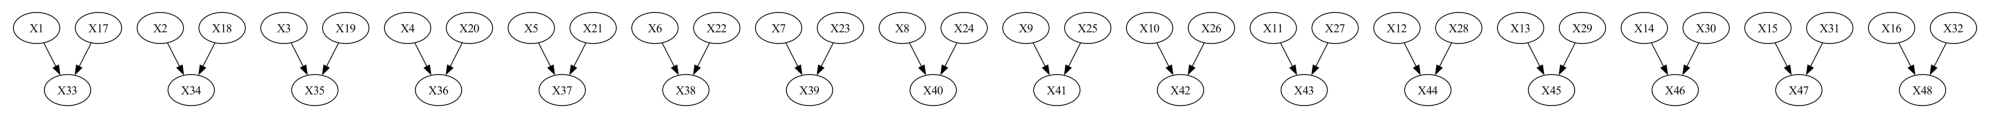

SHD @ n = 1000: 0.0


Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 1251.83it/s]


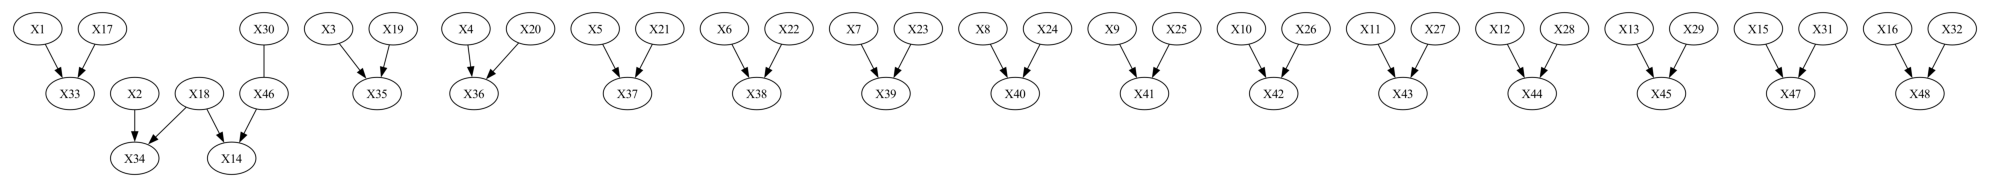

SHD @ n = 5000: 1.0


Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 1447.98it/s]


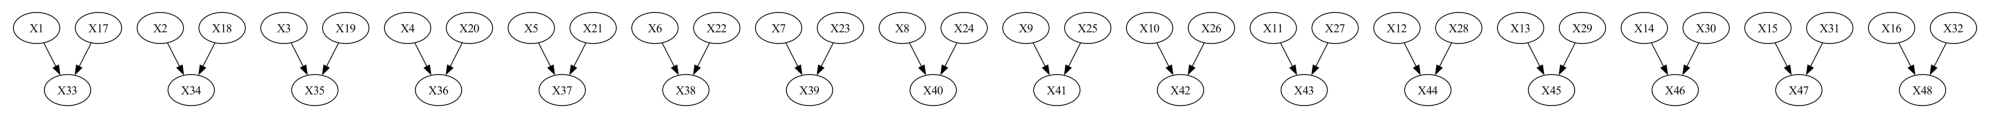

SHD @ n = 10000: 0.0


In [11]:
for df,n in zip(df_or_list,n_list):
    g_pred = pc(df.to_numpy(), indep_test = "chisq", alpha = alpha)

    # Visualization using pydot.
    g_pred.draw_pydot_graph()
    
    # Save the graph.
    pyd = GraphUtils.to_pydot(g_pred.G, labels = list(df.columns))
    pyd.write_png(f"pc_or_{n}.png")

    # Convert to networkx.
    a_pred = g_pred.G.graph.copy()
    a_pred = np.triu(a_pred)
    a_pred[a_pred == -1] = 1
    g_pred_nx = nx.from_numpy_array(a_pred, create_using = nx.DiGraph)

    # Evaluate.
    shd = structure_hamming_dist(g_true, g_pred_nx, double_for_anticausal = False)
    print(f"SHD @ n = {n}: {shd}")
    shd_and_list.append(shd)

## logical xor

Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 2949.67it/s]


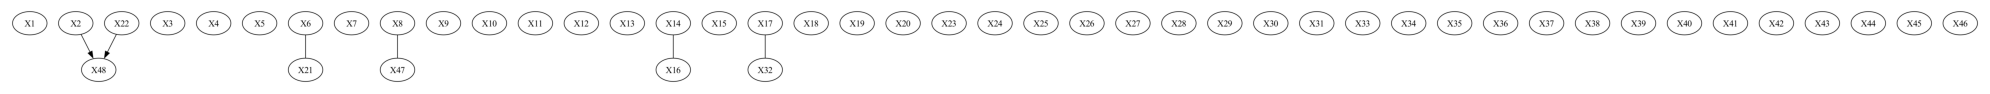

SHD @ n = 1000: 38.0


Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 3424.39it/s]


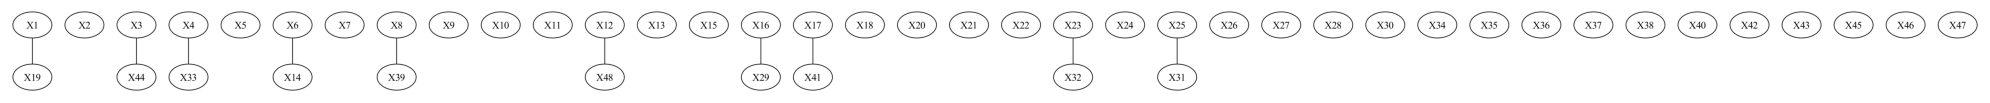

SHD @ n = 5000: 42.0


Depth=1, working on node 47: 100%|████████████| 48/48 [00:00<00:00, 3519.57it/s]


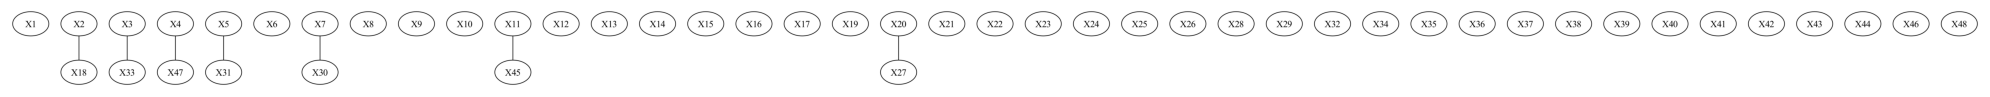

SHD @ n = 10000: 39.0


In [12]:
for df,n in zip(df_xor_list,n_list):
    g_pred = pc(df.to_numpy(), indep_test = "chisq", alpha = alpha)

    # Visualization using pydot.
    g_pred.draw_pydot_graph()

    # Save the graph.
    pyd = GraphUtils.to_pydot(g_pred.G, labels = list(df.columns))
    pyd.write_png(f"pc_xor_{n}.png")

    # Convert to networkx.
    a_pred = g_pred.G.graph.copy()
    a_pred = np.triu(a_pred)
    a_pred[a_pred == -1] = 1
    g_pred_nx = nx.from_numpy_array(a_pred, create_using = nx.DiGraph)

    # Evaluate.
    shd = structure_hamming_dist(g_true, g_pred_nx, double_for_anticausal = False)
    print(f"SHD @ n = {n}: {shd}")
    shd_and_list.append(shd)

# End of document